In [44]:
import pandas as pd
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Desempeño en Santiago (Validación):
MAE:  11.74 MWh (Error promedio por hora)
RMSE: 15.50 MWh


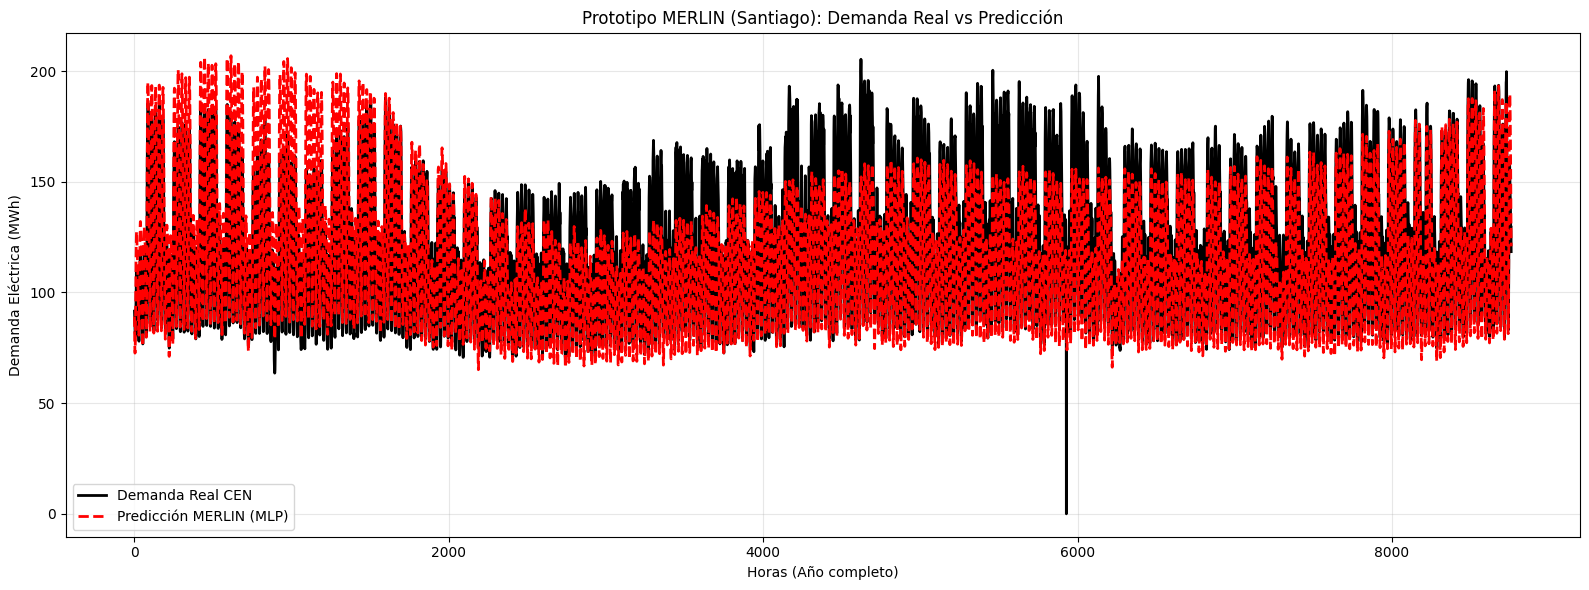

In [57]:

# 1. Cargar el modelo entrenado y el scaler de la variable "Y" (Demanda)
model = tf.keras.models.load_model('../models/best_merlin_mlp_stgo.keras')
scaler_y = joblib.load('../models/scaler_demand_santiago.pkl')

# 2. Cargar datos de Validación (o Test)
df_val = pd.read_parquet("../data/processed/val_merlin_stgo.parquet")
y_val_scaled = df_val['demanda_mwh'].values
X_val_scaled = df_val.drop(columns=['demanda_mwh']).values

# 3. Hacer predicciones (el resultado es un valor entre 0 y 1)
y_pred_scaled = model.predict(X_val_scaled)

# 4. DEVOLVER A ESCALA ORIGINAL (MWh)
# Transformamos la matriz (N, ) a (N, 1) porque scikit-learn lo exige
y_val_real = scaler_y.inverse_transform(y_val_scaled.reshape(-1, 1)).flatten()
y_pred_real = scaler_y.inverse_transform(y_pred_scaled).flatten()

# 5. Calcular Métricas de Desempeño
mae = mean_absolute_error(y_val_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_val_real, y_pred_real))
print(f"Desempeño en Santiago (Validación):")
print(f"MAE:  {mae:.2f} MWh (Error promedio por hora)")
print(f"RMSE: {rmse:.2f} MWh")

# 6. Gráfico de Verificación Fina (Visualizar 1 semana de Invierno)
# Supongamos que queremos ver las primeras 168 horas (1 semana)
inicio = 0 # Un punto arbitrario (ej. a mitad de año)
fin = 8760

plt.figure(figsize=(16, 6))
plt.plot(y_val_real[inicio:fin], label='Demanda Real CEN', color='black', linewidth=2)
plt.plot(y_pred_real[inicio:fin], label='Predicción MERLIN (MLP)', color='red', linestyle='--', linewidth=2)

plt.title('Prototipo MERLIN (Santiago): Demanda Real vs Predicción')
plt.xlabel('Horas (Año completo)')
plt.ylabel('Demanda Eléctrica (MWh)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()